In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

In [29]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices.csv"
)

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

In [32]:
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    errors="coerce"
)

In [34]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [35]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-02,512.1124,NaN
1,100016,2022-01-03,503.1674,-0.017467
2,100016,2022-01-04,531.2850,0.055881
3,100016,2022-01-06,474.1732,-0.107497
4,100016,2022-01-07,452.5840,-0.045530


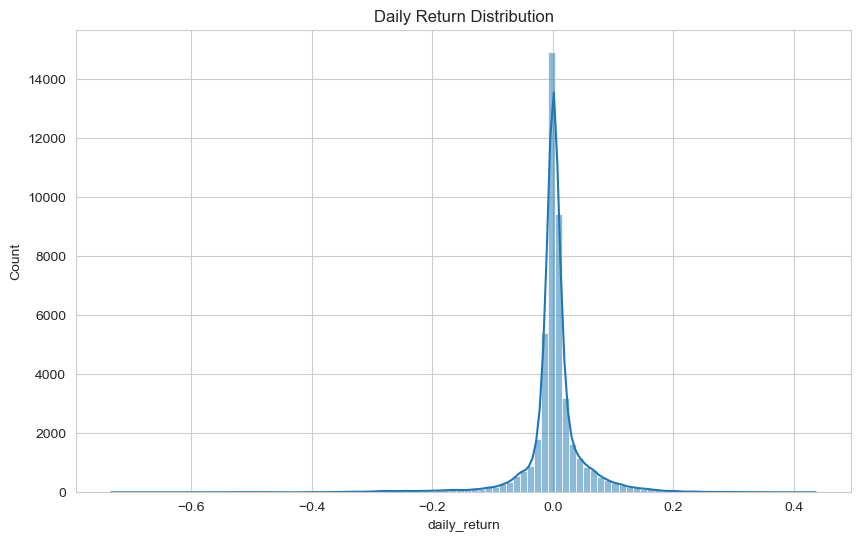

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

In [37]:
cagr_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    group = group.dropna(
        subset=["nav"]
    )

    if len(group) < 2:
        continue

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    if start_nav <= 0 or end_nav <= 0:
        continue

    years = (
        (group.iloc[-1]["date"] -
         group.iloc[0]["date"]).days
    ) / 365

    if years <= 0:
        continue

    cagr = (
        (end_nav / start_nav)
        ** (1/years)
    ) - 1

    cagr_list.append([
        code,
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,NaN
1,100025,NaN
2,100033,NaN
3,101206,NaN
4,101207,NaN


In [38]:
rf = 0.065

sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    mean_return = group[
        "daily_return"
    ].mean()

    std_return = group[
        "daily_return"
    ].std()

    sharpe = (
        (mean_return - rf/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append([
        code,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,0.254918
1,100025,0.023041
2,100033,0.765382
3,101206,0.629564
4,101207,0.506034


In [39]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    downside = group[
        group["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std()

    mean_return = group[
        "daily_return"
    ].mean()

    sortino = (
        (mean_return - rf/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_list.append([
        code,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,0.298665
1,100025,0.020312
2,100033,0.710308
3,101206,0.604758
4,101207,0.605644


In [40]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark[
    "close_value"
].pct_change()

In [41]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark,
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([
            code,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.938116,0.000008
1,100025,0.083925,0.000049
2,100033,1.369306,-0.000038
3,101206,1.129337,0.000161
4,101207,1.331529,-0.000797


In [42]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"]
        / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_list.append([
        code,
        max_dd
    ])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.384400
1,100025,-0.198731
2,100033,-0.742067
3,101206,-0.630039
4,101207,-0.521628


In [43]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown
0,100016,NaN,0.254918,0.938116,0.000008,-0.384400
1,100025,NaN,0.023041,0.083925,0.000049,-0.198731
2,100033,NaN,0.765382,1.369306,-0.000038,-0.742067
3,101206,NaN,0.629564,1.129337,0.000161,-0.630039
4,101207,NaN,0.506034,1.331529,-0.000797,-0.521628


In [44]:
scorecard["return_rank"] = scorecard[
    "cagr"
].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(ascending=False)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(ascending=False)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(ascending=True)

In [45]:
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30
    +
    scorecard["sharpe_rank"] * 0.25
    +
    scorecard["alpha_rank"] * 0.20
    +
    scorecard["drawdown_rank"] * 0.10
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
0,100016,NaN,0.254918,0.938116,0.000008,-0.384400,NaN,34.0,27.0,31.0,NaN
1,100025,NaN,0.023041,0.083925,0.000049,-0.198731,NaN,40.0,38.0,39.0,NaN
2,100033,NaN,0.765382,1.369306,-0.000038,-0.742067,NaN,9.0,15.0,3.0,NaN
3,101206,NaN,0.629564,1.129337,0.000161,-0.630039,NaN,15.0,20.0,12.0,NaN
4,101207,NaN,0.506034,1.331529,-0.000797,-0.521628,NaN,24.0,17.0,24.0,NaN


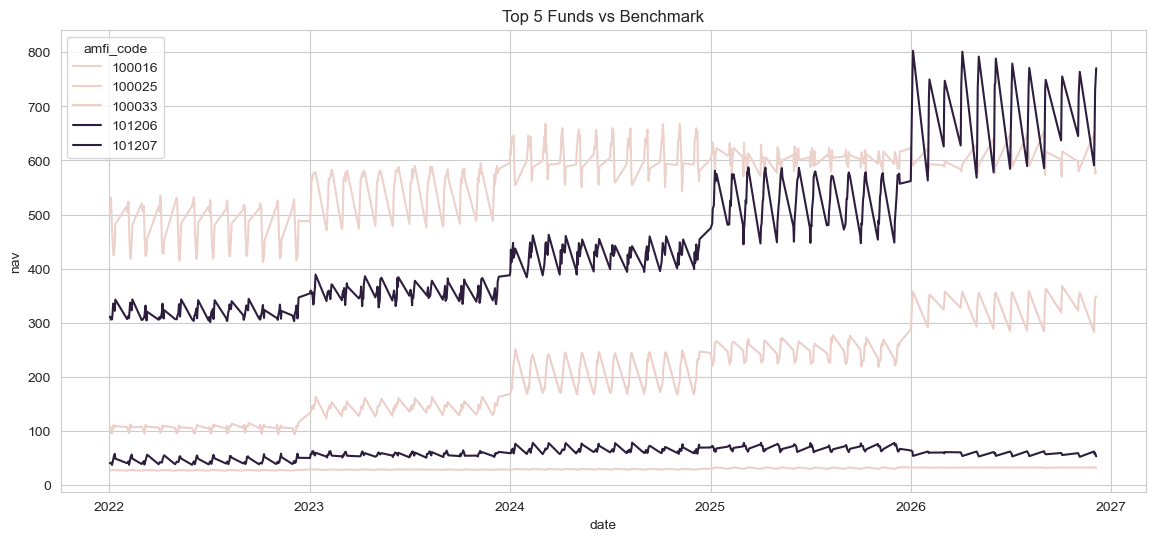

In [46]:
top5 = scorecard.nsmallest(
    5,
    "fund_score"
)["amfi_code"]

top_nav = nav[
    nav["amfi_code"].isin(top5)
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=top_nav,
    x="date",
    y="nav",
    hue="amfi_code"
)

plt.title("Top 5 Funds vs Benchmark")

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

In [47]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [48]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [49]:
print(nav["date"].isnull().sum())

27842


In [50]:
raw_nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

print(raw_nav["date"].head(20))

0     2022-01-02
1     2022-01-03
2     2022-01-04
3     2022-01-06
4     2022-01-07
5     2022-01-08
6     2022-01-09
7     2022-01-11
8     2022-01-12
9     2022-02-02
10    2022-02-03
11    2022-02-05
12    2022-02-06
13    2022-02-08
14    2022-02-09
15    2022-02-11
16    2022-02-12
17    2022-03-01
18    2022-03-02
19    2022-03-03
Name: date, dtype: object
